In [1]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.feature_extraction.text import TfidfVectorizer
import nltk
from nltk.corpus import stopwords
import pandas as pd
import string
import nltk

In [7]:
df=pd.read_csv("IMDB Dataset.csv")

In [8]:
df.isnull().sum()

,0
review,0
sentiment,0


In [10]:
df.isnull().sum()

,0
review,0
sentiment,0


In [12]:
df.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [11]:
nltk.download('stopwords')
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...


True

In [15]:
import pandas as pd
import nltk
import string
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer


nltk.download('punkt')
nltk.download('wordnet')
nltk.download('stopwords')

stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def preprocess_text(review):

    if pd.isna(review):
        return []


    text = str(review).strip()


    translator = str.maketrans('', '', string.punctuation)
    text = text.translate(translator)


    text = text.lower()


    tokens = nltk.word_tokenize(text)


    tokens = [word for word in tokens if word not in stop_words]


    tokens = [lemmatizer.lemmatize(word) for word in tokens]

    return tokens


df['processed_text'] = df['review'].apply(preprocess_text)


print(df.head())

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


                                              review sentiment  \
0  One of the other reviewers has mentioned that ...  positive   
1  A wonderful little production. <br /><br />The...  positive   
2  I thought this was a wonderful way to spend ti...  positive   
3  Basically there's a family where a little boy ...  negative   
4  Petter Mattei's "Love in the Time of Money" is...  positive   

                                      processed_text  
0  [one, reviewer, mentioned, watching, 1, oz, ep...  
1  [wonderful, little, production, br, br, filmin...  
2  [thought, wonderful, way, spend, time, hot, su...  
3  [basically, there, family, little, boy, jake, ...  
4  [petter, matteis, love, time, money, visually,...  


In [16]:
clean_sentences = df['processed_text'].apply(lambda x: ' '.join(x))

In [17]:
tfidf=TfidfVectorizer(stop_words='english')
X=tfidf.fit_transform(clean_sentences)

In [18]:
y = df['sentiment']

In [19]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix

In [20]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [21]:
model = LogisticRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

In [22]:
from sklearn.metrics import accuracy_score
accuracy = accuracy_score(y_test, y_pred)

print(f"Accuracy: {accuracy:.2f}")

Accuracy: 0.89


In [35]:
import numpy as np
import pandas as pd
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
import string
import os
import urllib.request
import zipfile
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import xgboost as xgb


nltk.download('stopwords')
nltk.download('punkt')
nltk.download('wordnet')

df = pd.read_csv("IMDB Dataset.csv")
df = df[['review', 'sentiment']]

df['sentiment_binary'] = (df['sentiment'] == 'positive').astype(int)

print(f"Dataset shape: {df.shape}")
print(f"Sentiment distribution:\n{df['sentiment_binary'].value_counts()}")

stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def preprocess_text(review):
    if pd.isna(review):
        return []

    text = str(review).strip()
    translator = str.maketrans('', '', string.punctuation)
    text = text.translate(translator)
    text = text.lower()
    tokens = nltk.word_tokenize(text)
    tokens = [word for word in tokens if word not in stop_words]
    tokens = [lemmatizer.lemmatize(word) for word in tokens]

    return tokens


print("\nPreprocessing reviews...")
df['processed_text'] = df['review'].apply(preprocess_text)

print("\nDownloading GloVe embeddings...")

glove_url = "http://nlp.stanford.edu/data/glove.6B.zip"
glove_file = "glove.6B.zip"
glove_dir = "glove.6B"


if not os.path.exists(glove_dir):
    print("Downloading glove.6B.zip (this may take a few minutes)...")
    urllib.request.urlretrieve(glove_url, glove_file)
    print("Extracting GloVe embeddings...")
    with zipfile.ZipFile(glove_file, 'r') as zip_ref:
        zip_ref.extractall(glove_dir)
    print("GloVe embeddings extracted!")
else:
    print("GloVe embeddings already downloaded!")

print("\nLoading GloVe embeddings (100-dimensional)...")

embedding_dim = 100
glove_file_path = os.path.join(glove_dir, "glove.6B.100d.txt")


embeddings_index = {}
with open(glove_file_path, 'r', encoding='utf-8') as f:
    for line in f:
        values = line.split()
        word = values[0]
        coefs = np.asarray(values[1:], dtype='float32')
        embeddings_index[word] = coefs

print(f"Loaded {len(embeddings_index)} word embeddings")


print("\nCreating averaged GloVe vectors for each review...")

def get_averaged_glove_vector(tokens, embeddings_index, embedding_dim=100):
    """
    Average the GloVe vectors for all tokens in a review.
    If no tokens have embeddings, return a zero vector.
    """
    vectors = []

    for token in tokens:
        if token in embeddings_index:
            vectors.append(embeddings_index[token])

    if len(vectors) == 0:

        return np.zeros(embedding_dim)


    return np.mean(vectors, axis=0)


X = np.array([get_averaged_glove_vector(tokens, embeddings_index, embedding_dim)
              for tokens in df['processed_text']])

y = df['sentiment_binary'].values

print(f"Feature matrix shape: {X.shape}")
print(f"Target shape: {y.shape}")


print("\nSplitting data into train and test sets...")
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training set size: {X_train.shape[0]}")
print(f"Test set size: {X_test.shape[0]}")


print("\nTraining XGBoost classifier...")


model = xgb.XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss',
    verbosity=1
)

model.fit(X_train, y_train)
print("Model training completed!")


print("\n" + "="*50)
print("MODEL EVALUATION")
print("="*50)


y_pred = model.predict(X_test)
y_pred_proba = model.predict_proba(X_test)


accuracy = accuracy_score(y_test, y_pred)
print(f"\nAccuracy: {accuracy:.4f}")


print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['Negative', 'Positive']))


print("\nConfusion Matrix:")
cm = confusion_matrix(y_test, y_pred)
print(cm)

print("\n" + "="*50)
print("TOP 10 MOST IMPORTANT FEATURES")
print("="*50)


importances = model.feature_importances_
top_indices = np.argsort(importances)[-10:][::-1]

for i, idx in enumerate(top_indices, 1):
    print(f"{i}. Feature {idx}: {importances[idx]:.4f}")


print("\n" + "="*50)
print("EXAMPLE PREDICTIONS ON TEST SET")
print("="*50)


for i in range(min(5, len(X_test))):
    actual = "Positive" if y_test[i] == 1 else "Negative"
    predicted = "Positive" if y_pred[i] == 1 else "Negative"
    confidence = max(y_pred_proba[i]) * 100

    print(f"\nExample {i+1}:")
    print(f"  Actual:      {actual}")
    print(f"  Predicted:   {predicted}")
    print(f"  Confidence:  {confidence:.2f}%")
    print(f"  Original text: {df['review'].iloc[i][:100]}...")

print("\n" + "="*50)
print("TRAINING COMPLETE!")
print("="*50)

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


Dataset shape: (50000, 3)
Sentiment distribution:
sentiment_binary
1    25000
0    25000
Name: count, dtype: int64

Preprocessing reviews...

GloVe embeddings already downloaded!

Loading GloVe embeddings (100-dimensional)...
Loaded 400000 word embeddings

Creating averaged GloVe vectors for each review...
Feature matrix shape: (50000, 100)
Target shape: (50000,)

Splitting data into train and test sets...
Training set size: 40000
Test set size: 10000

Training XGBoost classifier...
Model training completed!

MODEL EVALUATION

Accuracy: 0.7865

Classification Report:
              precision    recall  f1-score   support

    Negative       0.79      0.78      0.78      4961
    Positive       0.79      0.79      0.79      5039

    accuracy                           0.79     10000
   macro avg       0.79      0.79      0.79     10000
weighted avg       0.79      0.79      0.79     10000


Confusion Matrix:
[[3881 1080]
 [1055 3984]]

TOP 10 MOST IMPORTANT FEATURES
1. Feature 8: 0.0791


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


Loading IMDB dataset...
Dataset shape: (50000, 3)
Sentiment distribution:
sentiment_binary
1    25000
0    25000
Name: count, dtype: int64

Preprocessing reviews...

Tokenizing reviews...
Tokenizer vocabulary size: 170220
Padded sequences shape: (50000, 100)
Sample sequence shape: (100,)
Sample sequence (first 20 tokens): [   5 1032  950   67  383 3097  177  371 2954  108  506  494 1978    2
   24   28 3019 3097 5077    1]

Splitting data into train and test sets...
Training set size: 40000
Test set size: 10000

Building Bidirectional LSTM model...

MODEL ARCHITECTURE


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_lstm              │ ?                      │   0 (unbuilt) │
│ (Bidirectional)                 │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_hidden (Dense)            │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)


TRAINING WITH EARLY STOPPING

Training model...
Epoch 1/20
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 22s 14ms/step - accuracy: 0.8110 - loss: 0.4161 - val_accuracy: 0.8585 - val_loss: 0.3482
Epoch 2/20
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 14s 14ms/step - accuracy: 0.8942 - loss: 0.2706 - val_accuracy: 0.8615 - val_loss: 0.3479
Epoch 3/20
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 14s 14ms/step - accuracy: 0.9220 - loss: 0.2084 - val_accuracy: 0.8560 - val_loss: 0.3650
Epoch 4/20
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 20s 14ms/step - accuracy: 0.9441 - loss: 0.1536 - val_accuracy: 0.8491 - val_loss: 0.4094
Epoch 5/20
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 14s 14ms/step - accuracy: 0.9640 - loss: 0.1021 - val_accuracy: 0.8403 - val_loss: 0.5022
Epoch 5: early stopping
Restoring model weights from the end of the best epoch: 2.

MODEL EVALUATION ON TEST SET

Test Accuracy: 0.8675

Classification Report:
              precision    recall  f1-score   support

    Negative       0.90      0.82      0.86      4961
    Positive       0.8

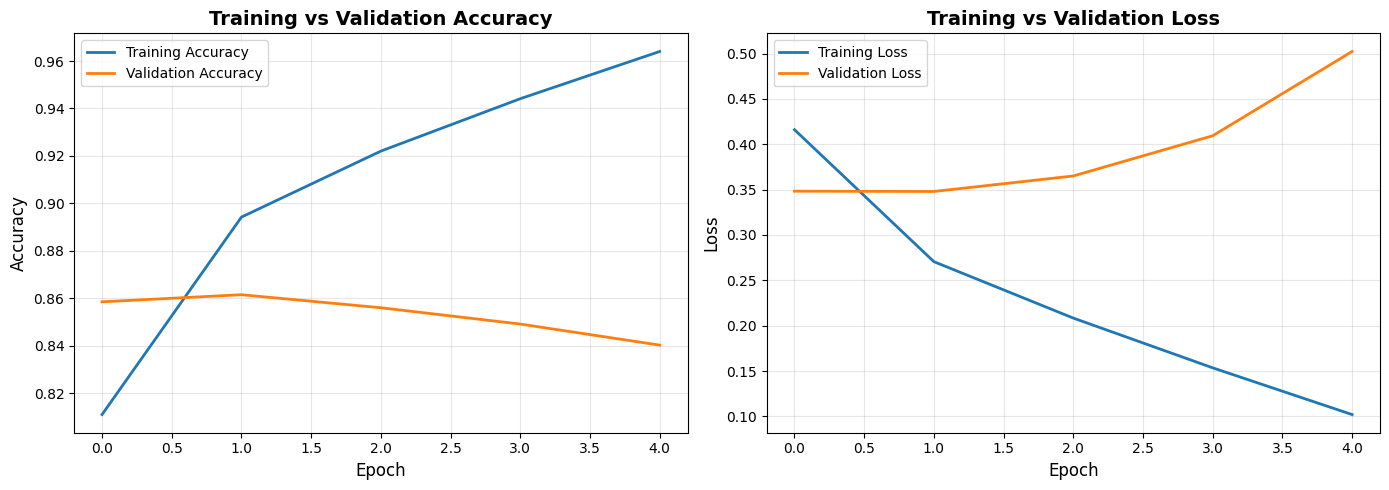

Training curves saved as 'bilstm_training_curves.png'

EXAMPLE PREDICTIONS ON TEST SET

Example 1:
  Actual:      Positive
  Predicted:   Positive
  Confidence:  74.76%
  Probability: 0.7476

Example 2:
  Actual:      Positive
  Predicted:   Positive
  Confidence:  99.59%
  Probability: 0.9959

Example 3:
  Actual:      Negative
  Predicted:   Negative
  Confidence:  97.42%
  Probability: 0.0258

Example 4:
  Actual:      Positive
  Predicted:   Positive
  Confidence:  99.10%
  Probability: 0.9910

Example 5:
  Actual:      Negative
  Predicted:   Negative
  Confidence:  97.50%
  Probability: 0.0250

TRAINING SUMMARY STATISTICS

Best Epoch: 2
Best Training Accuracy: 0.9640
Best Validation Accuracy: 0.8615
Best Training Loss: 0.1021
Best Validation Loss: 0.3479
Total Epochs Trained: 5

TRAINING COMPLETE!
Model saved as 'bilstm_sentiment_model.h5'


In [36]:
import numpy as np
import pandas as pd
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
import string
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Bidirectional, LSTM, Dropout, Dense
from tensorflow.keras.callbacks import EarlyStopping
import warnings
warnings.filterwarnings('ignore')


nltk.download('stopwords')
nltk.download('punkt')
nltk.download('wordnet')


print("Loading IMDB dataset...")
df = pd.read_csv("IMDB Dataset.csv")
df = df[['review', 'sentiment']]


df['sentiment_binary'] = (df['sentiment'] == 'positive').astype(int)

print(f"Dataset shape: {df.shape}")
print(f"Sentiment distribution:\n{df['sentiment_binary'].value_counts()}\n")


stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def preprocess_text(review):
    if pd.isna(review):
        return ""

    text = str(review).strip()
    translator = str.maketrans('', '', string.punctuation)
    text = text.translate(translator)
    text = text.lower()
    tokens = nltk.word_tokenize(text)
    tokens = [word for word in tokens if word not in stop_words]
    tokens = [lemmatizer.lemmatize(word) for word in tokens]

    return ' '.join(tokens)


print("Preprocessing reviews...")
df['processed_text'] = df['review'].apply(preprocess_text)


print("\nTokenizing reviews...")

vocab_size = 10000
max_length = 100
embedding_dim = 64


tokenizer = Tokenizer(num_words=vocab_size, oov_token='<OOV>')
tokenizer.fit_on_texts(df['processed_text'])


sequences = tokenizer.texts_to_sequences(df['processed_text'])


X = pad_sequences(sequences, maxlen=max_length, padding='post', truncating='post')
y = df['sentiment_binary'].values

print(f"Tokenizer vocabulary size: {len(tokenizer.word_index)}")
print(f"Padded sequences shape: {X.shape}")
print(f"Sample sequence shape: {X[0].shape}")
print(f"Sample sequence (first 20 tokens): {X[0][:20]}")


print("\nSplitting data into train and test sets...")
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training set size: {X_train.shape[0]}")
print(f"Test set size: {X_test.shape[0]}")


print("\nBuilding Bidirectional LSTM model...")

model = Sequential([

    Embedding(input_dim=vocab_size,
              output_dim=embedding_dim,
              input_length=max_length,
              name='embedding'),


    Bidirectional(LSTM(64, return_sequences=False), name='bidirectional_lstm'),


    Dropout(0.5, name='dropout_1'),


    Dense(32, activation='relu', name='dense_hidden'),


    Dropout(0.3, name='dropout_2'),


    Dense(1, activation='sigmoid', name='output')
])


model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)


print("\n" + "="*60)
print("MODEL ARCHITECTURE")
print("="*60)
model.summary()


print("\n" + "="*60)
print("TRAINING WITH EARLY STOPPING")
print("="*60)


early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True,
    verbose=1
)


print("\nTraining model...")
history = model.fit(
    X_train, y_train,
    epochs=20,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stopping],
    verbose=1
)


print("\n" + "="*60)
print("MODEL EVALUATION ON TEST SET")
print("="*60)


y_pred_proba = model.predict(X_test, verbose=0)
y_pred = (y_pred_proba > 0.5).astype(int).flatten()


test_accuracy = accuracy_score(y_test, y_pred)
print(f"\nTest Accuracy: {test_accuracy:.4f}")


print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['Negative', 'Positive']))


print("\nConfusion Matrix:")
cm = confusion_matrix(y_test, y_pred)
print(cm)


print("\n" + "="*60)
print("PLOTTING TRAINING CURVES")
print("="*60)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))


axes[0].plot(history.history['accuracy'], label='Training Accuracy', linewidth=2)
axes[0].plot(history.history['val_accuracy'], label='Validation Accuracy', linewidth=2)
axes[0].set_xlabel('Epoch', fontsize=12)
axes[0].set_ylabel('Accuracy', fontsize=12)
axes[0].set_title('Training vs Validation Accuracy', fontsize=14, fontweight='bold')
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)


axes[1].plot(history.history['loss'], label='Training Loss', linewidth=2)
axes[1].plot(history.history['val_loss'], label='Validation Loss', linewidth=2)
axes[1].set_xlabel('Epoch', fontsize=12)
axes[1].set_ylabel('Loss', fontsize=12)
axes[1].set_title('Training vs Validation Loss', fontsize=14, fontweight='bold')
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('bilstm_training_curves.png', dpi=300, bbox_inches='tight')
plt.show()

print("Training curves saved as 'bilstm_training_curves.png'")


print("\n" + "="*60)
print("EXAMPLE PREDICTIONS ON TEST SET")
print("="*60)


for i in range(min(5, len(X_test))):
    actual = "Positive" if y_test[i] == 1 else "Negative"
    predicted = "Positive" if y_pred[i] == 1 else "Negative"
    confidence = max(y_pred_proba[i][0], 1 - y_pred_proba[i][0]) * 100

    print(f"\nExample {i+1}:")
    print(f"  Actual:      {actual}")
    print(f"  Predicted:   {predicted}")
    print(f"  Confidence:  {confidence:.2f}%")
    print(f"  Probability: {y_pred_proba[i][0]:.4f}")


print("\n" + "="*60)
print("TRAINING SUMMARY STATISTICS")
print("="*60)

best_epoch = np.argmin(history.history['val_loss']) + 1
print(f"\nBest Epoch: {best_epoch}")
print(f"Best Training Accuracy: {max(history.history['accuracy']):.4f}")
print(f"Best Validation Accuracy: {max(history.history['val_accuracy']):.4f}")
print(f"Best Training Loss: {min(history.history['loss']):.4f}")
print(f"Best Validation Loss: {min(history.history['val_loss']):.4f}")
print(f"Total Epochs Trained: {len(history.history['loss'])}")

print("\n" + "="*60)
print("TRAINING COMPLETE!")
print("="*60)

# Save the model (optional)
model.save('bilstm_sentiment_model.h5')
print("Model saved as 'bilstm_sentiment_model.h5'")

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


UNIFIED MODEL COMPARISON: TF-IDF+LR vs GloVe+XGBoost vs BiLSTM

[STEP 1] Loading and preprocessing data...
Dataset shape: (50000, 4)
Preprocessing complete!

[STEP 2] Creating unified train-test split...
Test set size (held-out): 10000
Training+validation set size: 40000

MODEL 1: TF-IDF + LOGISTIC REGRESSION

[Training] TF-IDF + Logistic Regression...
Test Accuracy: 0.8834
Test F1-Score: 0.8859
Test ROC-AUC: 0.9543

MODEL 2: GloVe + XGBoost

[Preprocessing] Downloading GloVe embeddings...
GloVe embeddings already available!

[Loading] GloVe embeddings (100-dimensional)...
Loaded 400000 word embeddings

[Creating] averaged GloVe vectors...

[Training] XGBoost classifier...
Test Accuracy: 0.7881
Test F1-Score: 0.7898
Test ROC-AUC: 0.8694

MODEL 3: BIDIRECTIONAL LSTM

[Tokenizing] reviews for BiLSTM...

[Building] Bidirectional LSTM model...

[Training] BiLSTM model...
Test Accuracy: 0.8670
Test F1-Score: 0.8699
Test ROC-AUC: 0.9372

COMPREHENSIVE MODEL COMPARISON

                      

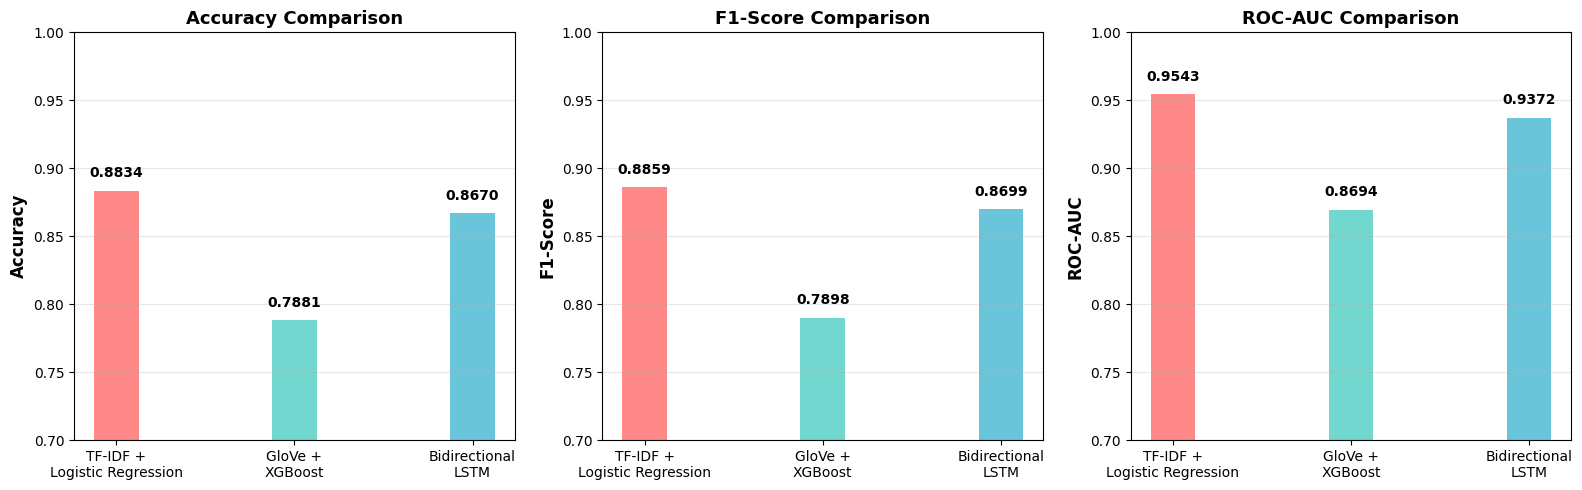

Saved: model_comparison_bars.png


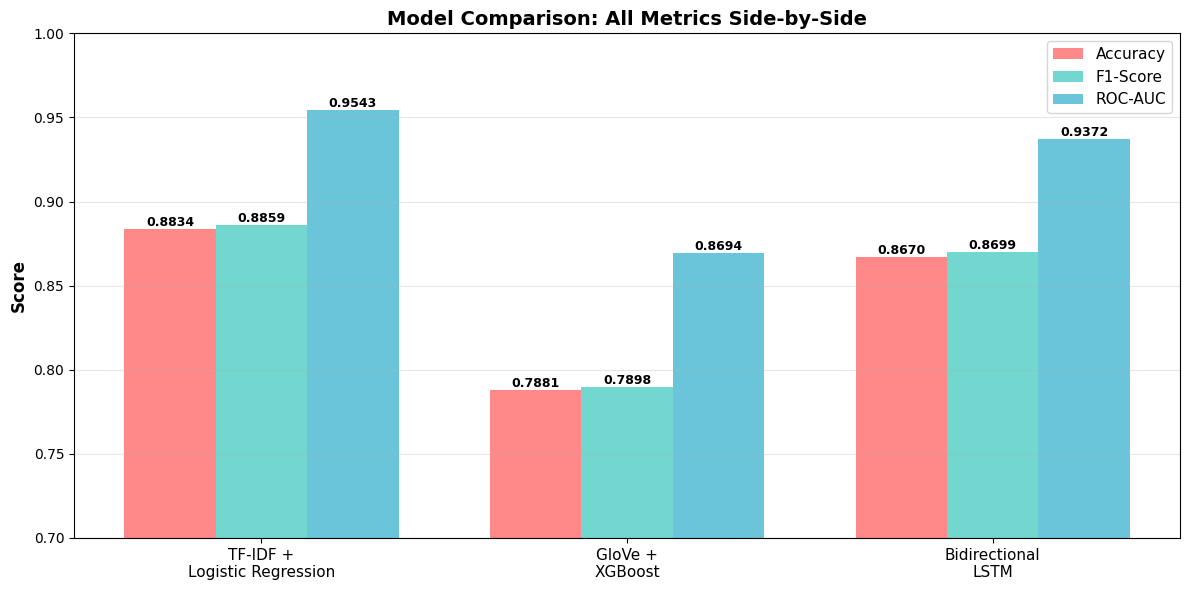

Saved: model_comparison_grouped.png

[Creating] ROC curves...


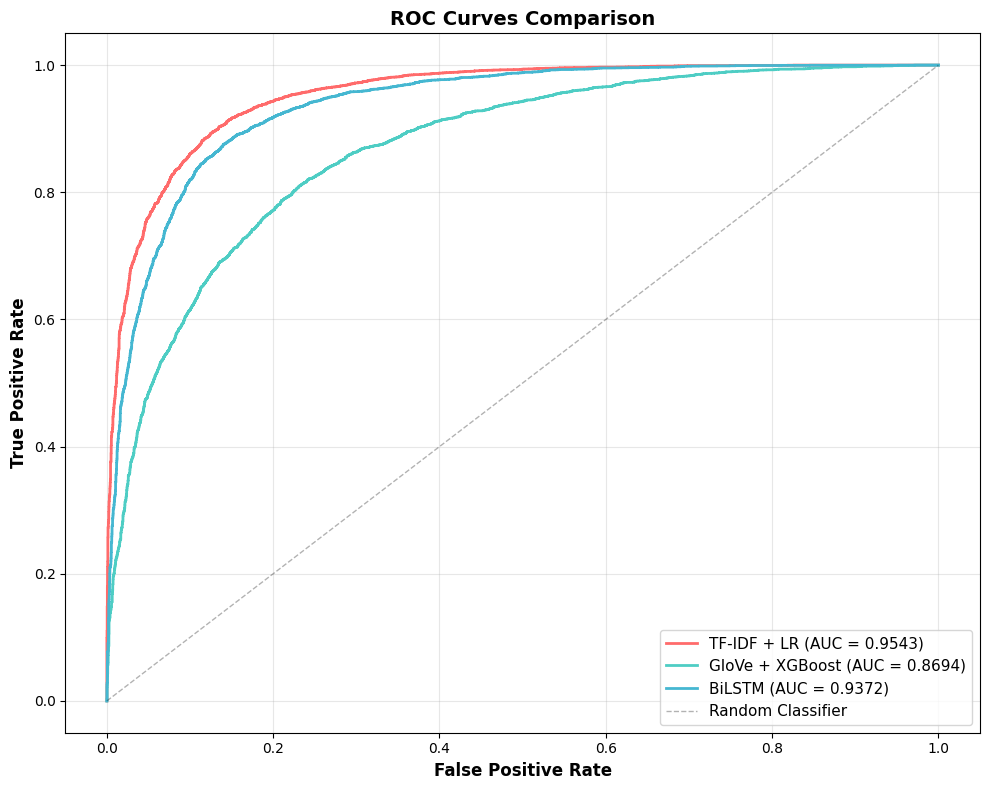

Saved: roc_curves_comparison.png

[Creating] confusion matrices...


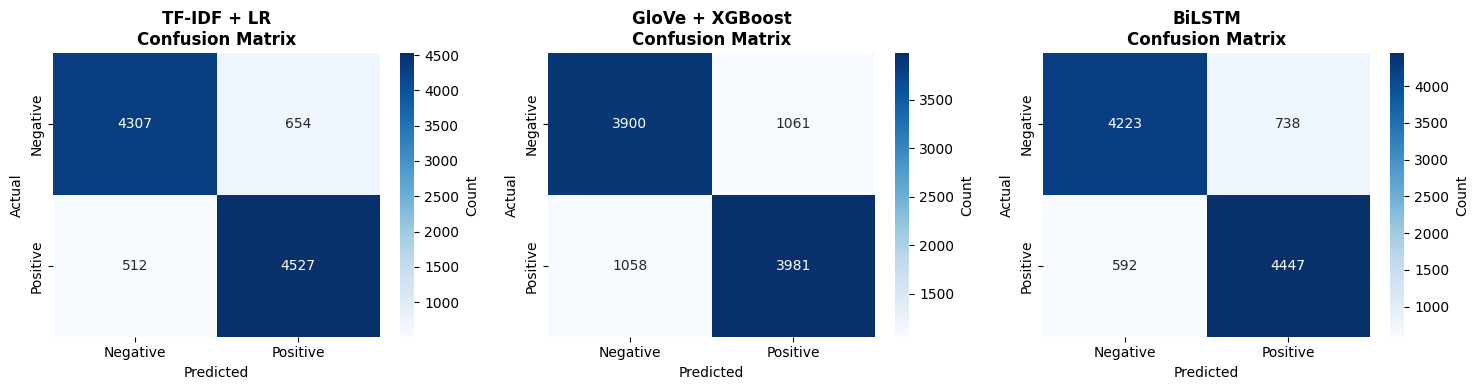

Saved: confusion_matrices_comparison.png

FINAL SUMMARY TABLE

  Metric TF-IDF + LR GloVe + XGBoost BiLSTM
Accuracy      0.8834          0.7881 0.8670
F1-Score      0.8859          0.7898 0.8699
 ROC-AUC      0.9543          0.8694 0.9372

EVALUATION COMPLETE!

Generated Visualizations:
  1. model_comparison_bars.png - Individual metric bar charts
  2. model_comparison_grouped.png - All metrics grouped by model
  3. roc_curves_comparison.png - ROC curves for all models
  4. confusion_matrices_comparison.png - Confusion matrices for all models


In [37]:
import numpy as np
import pandas as pd
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
import string
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, f1_score, roc_auc_score,
                             roc_curve, auc, classification_report, confusion_matrix)
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
import xgboost as xgb
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Bidirectional, LSTM, Dropout, Dense
from tensorflow.keras.callbacks import EarlyStopping
import warnings
warnings.filterwarnings('ignore')


nltk.download('stopwords')
nltk.download('punkt')
nltk.download('wordnet')

print("="*80)
print("UNIFIED MODEL COMPARISON: TF-IDF+LR vs GloVe+XGBoost vs BiLSTM")
print("="*80)


print("\n[STEP 1] Loading and preprocessing data...")
df = pd.read_csv("IMDB Dataset.csv")
df = df[['review', 'sentiment']]
df['sentiment_binary'] = (df['sentiment'] == 'positive').astype(int)

stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def preprocess_text(review):
    if pd.isna(review):
        return ""

    text = str(review).strip()
    translator = str.maketrans('', '', string.punctuation)
    text = text.translate(translator)
    text = text.lower()
    tokens = nltk.word_tokenize(text)
    tokens = [word for word in tokens if word not in stop_words]
    tokens = [lemmatizer.lemmatize(word) for word in tokens]

    return ' '.join(tokens)

df['processed_text'] = df['review'].apply(preprocess_text)
print(f"Dataset shape: {df.shape}")
print(f"Preprocessing complete!")


print("\n[STEP 2] Creating unified train-test split...")


X_temp, X_test_unified, y_temp, y_test_unified = train_test_split(
    df['processed_text'],
    df['sentiment_binary'],
    test_size=0.2,
    random_state=42
)


test_reviews_original = X_test_unified.values
test_reviews_processed = X_test_unified.values
test_labels = y_test_unified.values

print(f"Test set size (held-out): {len(X_test_unified)}")
print(f"Training+validation set size: {len(X_temp)}")


print("\n" + "="*80)
print("MODEL 1: TF-IDF + LOGISTIC REGRESSION")
print("="*80)

print("\n[Training] TF-IDF + Logistic Regression...")


X_train_tfidf, X_val_tfidf, y_train_tfidf, y_val_tfidf = train_test_split(
    X_temp, y_temp, test_size=0.2, random_state=42
)


tfidf = TfidfVectorizer(stop_words='english', max_features=5000)
X_train_tfidf_vec = tfidf.fit_transform(X_train_tfidf)
X_val_tfidf_vec = tfidf.transform(X_val_tfidf)
X_test_tfidf_vec = tfidf.transform(X_test_unified)


lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train_tfidf_vec, y_train_tfidf)


y_pred_lr = lr_model.predict(X_test_tfidf_vec)
y_pred_proba_lr = lr_model.predict_proba(X_test_tfidf_vec)[:, 1]


accuracy_lr = accuracy_score(test_labels, y_pred_lr)
f1_lr = f1_score(test_labels, y_pred_lr)
roc_auc_lr = roc_auc_score(test_labels, y_pred_proba_lr)

print(f"Test Accuracy: {accuracy_lr:.4f}")
print(f"Test F1-Score: {f1_lr:.4f}")
print(f"Test ROC-AUC: {roc_auc_lr:.4f}")


print("\n" + "="*80)
print("MODEL 2: GloVe + XGBoost")
print("="*80)

print("\n[Preprocessing] Downloading GloVe embeddings...")

import os
import urllib.request
import zipfile

glove_url = "http://nlp.stanford.edu/data/glove.6B.zip"
glove_file = "glove.6B.zip"
glove_dir = "glove.6B"

if not os.path.exists(glove_dir):
    print("Downloading glove.6B.zip...")
    urllib.request.urlretrieve(glove_url, glove_file)
    print("Extracting GloVe embeddings...")
    with zipfile.ZipFile(glove_file, 'r') as zip_ref:
        zip_ref.extractall(glove_dir)
    print("GloVe embeddings extracted!")
else:
    print("GloVe embeddings already available!")


print("\n[Loading] GloVe embeddings (100-dimensional)...")
embedding_dim = 100
glove_file_path = os.path.join(glove_dir, "glove.6B.100d.txt")

embeddings_index = {}
with open(glove_file_path, 'r', encoding='utf-8') as f:
    for line in f:
        values = line.split()
        word = values[0]
        coefs = np.asarray(values[1:], dtype='float32')
        embeddings_index[word] = coefs

print(f"Loaded {len(embeddings_index)} word embeddings")


def get_tokens(text):
    if pd.isna(text):
        return []
    text = str(text).strip()
    translator = str.maketrans('', '', string.punctuation)
    text = text.translate(translator)
    text = text.lower()
    tokens = nltk.word_tokenize(text)
    tokens = [word for word in tokens if word not in stop_words]
    tokens = [lemmatizer.lemmatize(word) for word in tokens]
    return tokens

def get_averaged_glove_vector(tokens, embeddings_index, embedding_dim=100):
    vectors = []
    for token in tokens:
        if token in embeddings_index:
            vectors.append(embeddings_index[token])
    if len(vectors) == 0:
        return np.zeros(embedding_dim)
    return np.mean(vectors, axis=0)


print("\n[Creating] averaged GloVe vectors...")
all_tokens = [get_tokens(text) for text in df['processed_text']]
X_glove_all = np.array([get_averaged_glove_vector(tokens, embeddings_index, embedding_dim)
                        for tokens in all_tokens])


train_indices = X_temp.index
test_indices = X_test_unified.index

X_train_glove = X_glove_all[train_indices]
X_test_glove = X_glove_all[test_indices]


X_train_glove_split, X_val_glove, y_train_glove_split, y_val_glove = train_test_split(
    X_train_glove, y_temp, test_size=0.2, random_state=42
)


print("\n[Training] XGBoost classifier...")
xgb_model = xgb.XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss',
    verbosity=0
)

xgb_model.fit(X_train_glove_split, y_train_glove_split)


y_pred_xgb = xgb_model.predict(X_test_glove)
y_pred_proba_xgb = xgb_model.predict_proba(X_test_glove)[:, 1]


accuracy_xgb = accuracy_score(test_labels, y_pred_xgb)
f1_xgb = f1_score(test_labels, y_pred_xgb)
roc_auc_xgb = roc_auc_score(test_labels, y_pred_proba_xgb)

print(f"Test Accuracy: {accuracy_xgb:.4f}")
print(f"Test F1-Score: {f1_xgb:.4f}")
print(f"Test ROC-AUC: {roc_auc_xgb:.4f}")


print("\n" + "="*80)
print("MODEL 3: BIDIRECTIONAL LSTM")
print("="*80)

print("\n[Tokenizing] reviews for BiLSTM...")


vocab_size = 10000
max_length = 100


tokenizer = Tokenizer(num_words=vocab_size, oov_token='<OOV>')
tokenizer.fit_on_texts(df['processed_text'])


sequences_all = tokenizer.texts_to_sequences(df['processed_text'])
X_sequences_all = pad_sequences(sequences_all, maxlen=max_length, padding='post', truncating='post')


X_train_lstm = X_sequences_all[train_indices]
X_test_lstm = X_sequences_all[test_indices]


X_train_lstm_split, X_val_lstm, y_train_lstm_split, y_val_lstm = train_test_split(
    X_train_lstm, y_temp, test_size=0.2, random_state=42
)

print("\n[Building] Bidirectional LSTM model...")


lstm_model = Sequential([
    Embedding(input_dim=vocab_size, output_dim=64, input_length=max_length),
    Bidirectional(LSTM(64, return_sequences=False)),
    Dropout(0.5),
    Dense(32, activation='relu'),
    Dropout(0.3),
    Dense(1, activation='sigmoid')
])

lstm_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

print("\n[Training] BiLSTM model...")


early_stopping = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True, verbose=0)
lstm_history = lstm_model.fit(
    X_train_lstm_split, y_train_lstm_split,
    epochs=20,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stopping],
    verbose=0
)


y_pred_proba_lstm = lstm_model.predict(X_test_lstm, verbose=0).flatten()
y_pred_lstm = (y_pred_proba_lstm > 0.5).astype(int)


accuracy_lstm = accuracy_score(test_labels, y_pred_lstm)
f1_lstm = f1_score(test_labels, y_pred_lstm)
roc_auc_lstm = roc_auc_score(test_labels, y_pred_proba_lstm)

print(f"Test Accuracy: {accuracy_lstm:.4f}")
print(f"Test F1-Score: {f1_lstm:.4f}")
print(f"Test ROC-AUC: {roc_auc_lstm:.4f}")


print("\n" + "="*80)
print("COMPREHENSIVE MODEL COMPARISON")
print("="*80)


comparison_df = pd.DataFrame({
    'Model': ['TF-IDF + Logistic Regression', 'GloVe + XGBoost', 'Bidirectional LSTM'],
    'Accuracy': [accuracy_lr, accuracy_xgb, accuracy_lstm],
    'F1-Score': [f1_lr, f1_xgb, f1_lstm],
    'ROC-AUC': [roc_auc_lr, roc_auc_xgb, roc_auc_lstm]
})

print("\n" + comparison_df.to_string(index=False))


print("\n" + "-"*80)
print("BEST PERFORMING MODELS:")
print("-"*80)
print(f"Best Accuracy:  {comparison_df.loc[comparison_df['Accuracy'].idxmax(), 'Model']} ({comparison_df['Accuracy'].max():.4f})")
print(f"Best F1-Score:  {comparison_df.loc[comparison_df['F1-Score'].idxmax(), 'Model']} ({comparison_df['F1-Score'].max():.4f})")
print(f"Best ROC-AUC:   {comparison_df.loc[comparison_df['ROC-AUC'].idxmax(), 'Model']} ({comparison_df['ROC-AUC'].max():.4f})")


print("\n" + "="*80)
print("DETAILED CLASSIFICATION REPORTS")
print("="*80)

print("\n--- TF-IDF + LOGISTIC REGRESSION ---")
print(classification_report(test_labels, y_pred_lr, target_names=['Negative', 'Positive']))

print("\n--- GloVe + XGBoost ---")
print(classification_report(test_labels, y_pred_xgb, target_names=['Negative', 'Positive']))

print("\n--- BIDIRECTIONAL LSTM ---")
print(classification_report(test_labels, y_pred_lstm, target_names=['Negative', 'Positive']))


print("\n[Creating] comparison visualizations...")

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

models = ['TF-IDF +\nLogistic Regression', 'GloVe +\nXGBoost', 'Bidirectional\nLSTM']
x_pos = np.arange(len(models))
bar_width = 0.25


accuracy_values = [accuracy_lr, accuracy_xgb, accuracy_lstm]
axes[0].bar(x_pos, accuracy_values, bar_width, color=['#FF6B6B', '#4ECDC4', '#45B7D1'], alpha=0.8)
axes[0].set_ylabel('Accuracy', fontsize=12, fontweight='bold')
axes[0].set_title('Accuracy Comparison', fontsize=13, fontweight='bold')
axes[0].set_xticks(x_pos)
axes[0].set_xticklabels(models, fontsize=10)
axes[0].set_ylim([0.7, 1.0])
axes[0].grid(axis='y', alpha=0.3)
for i, v in enumerate(accuracy_values):
    axes[0].text(i, v + 0.01, f'{v:.4f}', ha='center', fontweight='bold')


f1_values = [f1_lr, f1_xgb, f1_lstm]
axes[1].bar(x_pos, f1_values, bar_width, color=['#FF6B6B', '#4ECDC4', '#45B7D1'], alpha=0.8)
axes[1].set_ylabel('F1-Score', fontsize=12, fontweight='bold')
axes[1].set_title('F1-Score Comparison', fontsize=13, fontweight='bold')
axes[1].set_xticks(x_pos)
axes[1].set_xticklabels(models, fontsize=10)
axes[1].set_ylim([0.7, 1.0])
axes[1].grid(axis='y', alpha=0.3)
for i, v in enumerate(f1_values):
    axes[1].text(i, v + 0.01, f'{v:.4f}', ha='center', fontweight='bold')


roc_auc_values = [roc_auc_lr, roc_auc_xgb, roc_auc_lstm]
axes[2].bar(x_pos, roc_auc_values, bar_width, color=['#FF6B6B', '#4ECDC4', '#45B7D1'], alpha=0.8)
axes[2].set_ylabel('ROC-AUC', fontsize=12, fontweight='bold')
axes[2].set_title('ROC-AUC Comparison', fontsize=13, fontweight='bold')
axes[2].set_xticks(x_pos)
axes[2].set_xticklabels(models, fontsize=10)
axes[2].set_ylim([0.7, 1.0])
axes[2].grid(axis='y', alpha=0.3)
for i, v in enumerate(roc_auc_values):
    axes[2].text(i, v + 0.01, f'{v:.4f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('model_comparison_bars.png', dpi=300, bbox_inches='tight')
plt.show()
print("Saved: model_comparison_bars.png")

fig, ax = plt.subplots(figsize=(12, 6))

x = np.arange(len(models))
width = 0.25

bars1 = ax.bar(x - width, accuracy_values, width, label='Accuracy', color='#FF6B6B', alpha=0.8)
bars2 = ax.bar(x, f1_values, width, label='F1-Score', color='#4ECDC4', alpha=0.8)
bars3 = ax.bar(x + width, roc_auc_values, width, label='ROC-AUC', color='#45B7D1', alpha=0.8)

ax.set_ylabel('Score', fontsize=12, fontweight='bold')
ax.set_title('Model Comparison: All Metrics Side-by-Side', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(models, fontsize=11)
ax.legend(fontsize=11)
ax.set_ylim([0.7, 1.0])
ax.grid(axis='y', alpha=0.3)


for bars in [bars1, bars2, bars3]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.4f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig('model_comparison_grouped.png', dpi=300, bbox_inches='tight')
plt.show()
print("Saved: model_comparison_grouped.png")


print("\n[Creating] ROC curves...")

fig, ax = plt.subplots(figsize=(10, 8))


fpr_lr, tpr_lr, _ = roc_curve(test_labels, y_pred_proba_lr)
fpr_xgb, tpr_xgb, _ = roc_curve(test_labels, y_pred_proba_xgb)
fpr_lstm, tpr_lstm, _ = roc_curve(test_labels, y_pred_proba_lstm)


ax.plot(fpr_lr, tpr_lr, label=f'TF-IDF + LR (AUC = {roc_auc_lr:.4f})', linewidth=2, color='#FF6B6B')
ax.plot(fpr_xgb, tpr_xgb, label=f'GloVe + XGBoost (AUC = {roc_auc_xgb:.4f})', linewidth=2, color='#4ECDC4')
ax.plot(fpr_lstm, tpr_lstm, label=f'BiLSTM (AUC = {roc_auc_lstm:.4f})', linewidth=2, color='#45B7D1')


ax.plot([0, 1], [0, 1], 'k--', linewidth=1, alpha=0.3, label='Random Classifier')

ax.set_xlabel('False Positive Rate', fontsize=12, fontweight='bold')
ax.set_ylabel('True Positive Rate', fontsize=12, fontweight='bold')
ax.set_title('ROC Curves Comparison', fontsize=14, fontweight='bold')
ax.legend(fontsize=11, loc='lower right')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('roc_curves_comparison.png', dpi=300, bbox_inches='tight')
plt.show()
print("Saved: roc_curves_comparison.png")


print("\n[Creating] confusion matrices...")

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

cm_lr = confusion_matrix(test_labels, y_pred_lr)
cm_xgb = confusion_matrix(test_labels, y_pred_xgb)
cm_lstm = confusion_matrix(test_labels, y_pred_lstm)

for idx, (cm, title) in enumerate([(cm_lr, 'TF-IDF + LR'),
                                     (cm_xgb, 'GloVe + XGBoost'),
                                     (cm_lstm, 'BiLSTM')]):
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[idx],
                xticklabels=['Negative', 'Positive'],
                yticklabels=['Negative', 'Positive'],
                cbar_kws={'label': 'Count'})
    axes[idx].set_title(f'{title}\nConfusion Matrix', fontsize=12, fontweight='bold')
    axes[idx].set_ylabel('Actual', fontsize=10)
    axes[idx].set_xlabel('Predicted', fontsize=10)

plt.tight_layout()
plt.savefig('confusion_matrices_comparison.png', dpi=300, bbox_inches='tight')
plt.show()
print("Saved: confusion_matrices_comparison.png")


print("\n" + "="*80)
print("FINAL SUMMARY TABLE")
print("="*80 + "\n")

summary_table = pd.DataFrame({
    'Metric': ['Accuracy', 'F1-Score', 'ROC-AUC'],
    'TF-IDF + LR': [f'{accuracy_lr:.4f}', f'{f1_lr:.4f}', f'{roc_auc_lr:.4f}'],
    'GloVe + XGBoost': [f'{accuracy_xgb:.4f}', f'{f1_xgb:.4f}', f'{roc_auc_xgb:.4f}'],
    'BiLSTM': [f'{accuracy_lstm:.4f}', f'{f1_lstm:.4f}', f'{roc_auc_lstm:.4f}']
})

print(summary_table.to_string(index=False))

print("\n" + "="*80)
print("EVALUATION COMPLETE!")
print("="*80)
print("\nGenerated Visualizations:")
print("  1. model_comparison_bars.png - Individual metric bar charts")
print("  2. model_comparison_grouped.png - All metrics grouped by model")
print("  3. roc_curves_comparison.png - ROC curves for all models")
print("  4. confusion_matrices_comparison.png - Confusion matrices for all models")